In [1]:
from itertools import product
import pickle
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from popsummary.popresult import PopulationResult
from astropy.cosmology import Planck15
from astropy import units as u


plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

In [2]:
def q_flat(x):
    ans=1/(5-(-15))

    return ans


def kl_divergence_kde_p_known_q(p_samples, q_pdf, base=np.e, bandwidth='scott'):
    """
    Estimate KL divergence D_KL(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated KL divergence D_KL(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde = gaussian_kde(p_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde(p_samples)
    q_vals = q_pdf(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_vals = np.clip(q_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_vals)
    kl = np.mean(log_ratio)

    return kl / np.log(base)


def kl_divergence_kde(p_samples, q_samples, base=np.e, bandwidth='scott'):
    """
    Estimate delta divergence D_delta(P || Q) where:
      - P is known via samples (estimated with KDE)
      - Q is known via samples (estimated with KDE)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_samples (array): 1D array of samples from Q
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated delta divergence D_delta(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde_p = gaussian_kde(p_samples, bw_method=bandwidth)

    q_samples = np.asarray(q_samples)
    kde_q = gaussian_kde(q_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde_p(p_samples)
    q_kde_vals = kde_q(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_kde_vals = np.clip(q_kde_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_kde_vals)
    delta = np.mean(log_ratio)

    return delta / np.log(base)

## Use LVK population analysis results as `true' population

In [3]:
gwtc5 = '/home/tristan-bruel/Documents/Science/LVK/gwtc5'
zeval = 0.2
spm_color = '#CD5C5C'

strong_bbh_O4b = PopulationResult(fname=f'{gwtc5}/popsummary_files/gwtc5_updated_default_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_PowerLawRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5')
strong_bbh_O4b_z_grid, strong_bbh_O4b_Rz = strong_bbh_O4b.get_rates_on_grids('redshift')
strong_bbh_O4b_z_grid = strong_bbh_O4b_z_grid.reshape((strong_bbh_O4b_z_grid.size, ))
strong_bbh_O4b_m1_grid, strong_bbh_O4b_Rm1 = strong_bbh_O4b.get_rates_on_grids('mass_1')
strong_bbh_O4b_m1_grid = strong_bbh_O4b_m1_grid.reshape((strong_bbh_O4b_m1_grid.size, ))
strong_bbh_O4b_q_grid, strong_bbh_O4b_Rq = strong_bbh_O4b.get_rates_on_grids('mass_ratio')
strong_bbh_O4b_q_grid = strong_bbh_O4b_q_grid.reshape((strong_bbh_O4b_q_grid.size, ))
redshift_factor_strong_bbh_o4b = (1 + zeval)**(strong_bbh_O4b.get_hyperparameter_samples(hyperparameters=['lamb']))

opening existing popsummary file: /home/tristan-bruel/Documents/Science/LVK/gwtc5/popsummary_files/gwtc5_updated_default_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_PowerLawRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


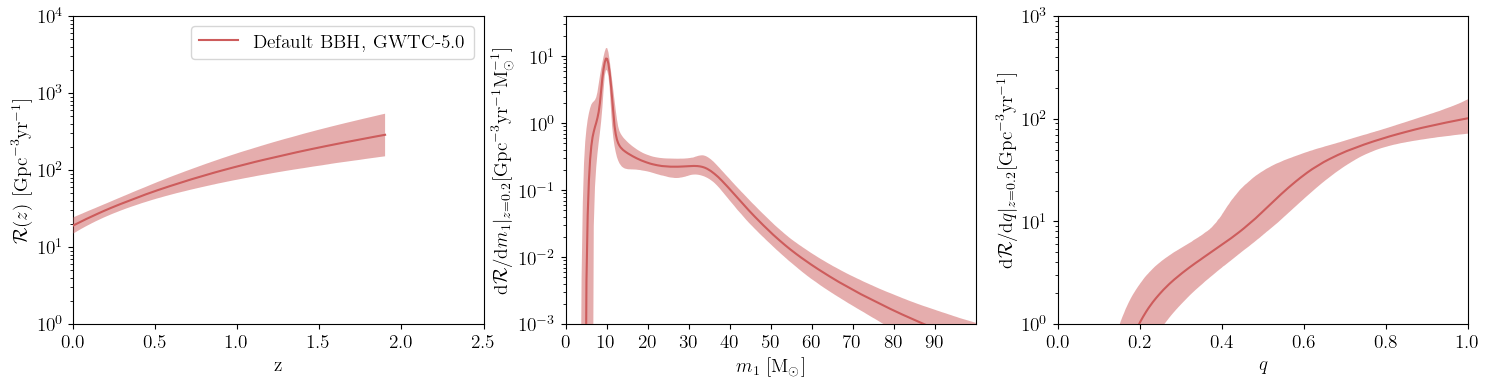

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

# Merger rate with redshift #
ax = axes[0]
ax.plot(strong_bbh_O4b_z_grid, np.quantile(strong_bbh_O4b_Rz, 0.5, axis = 0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
ax.fill_between(strong_bbh_O4b_z_grid,
        np.quantile(strong_bbh_O4b_Rz, 0.05, axis=0),
        np.quantile(strong_bbh_O4b_Rz, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)

ax.set_xlabel('z')
ax.set_xlim(xmin=0, xmax=2.5)
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1, ymax=1e4)
ax.legend()

# Primary mass #
ax = axes[1]
ax.plot(strong_bbh_O4b_m1_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.5, axis=0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
ax.fill_between(strong_bbh_O4b_m1_grid,
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.05, axis=0),
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
ax.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
ax.set_xlim(xmin=0, xmax=100)
ax.set_xticks(np.linspace(0,90,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=0.2} [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_\odot^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e-3, ymax=4e1)
#ax.legend(loc='upper right', frameon=False)

# Mass ratio #
ax = axes[2]
ax.plot(strong_bbh_O4b_q_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.5, axis=0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
ax.fill_between(strong_bbh_O4b_q_grid,
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.05, axis=0),
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
ax.set_xlabel(r'$q$')
ax.set_xlim(xmin=0, xmax=1)
ax.set_xticks(np.linspace(0,1,6))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=0.2} [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e0, ymax=1e3)
#ax.legend(loc='upper left', frameon=False)


plt.show()
plt.close()

In [5]:
print('R(z=%.2f), integral dR/dm1, integral dR/dq' %zeval)
for ind in range(3):
    Rzeval = interp1d(strong_bbh_O4b_z_grid, strong_bbh_O4b_Rz[ind,:])(zeval)
    int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[ind])
    int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[ind])
    print(Rzeval, int_dRdm1, int_dRdq)

R(z=0.20), integral dR/dm1, integral dR/dq
43.85726547616642 43.85646880807036 43.85646880807036
28.035447937840907 28.035349171744507 28.035349171744503
32.88557393041641 32.88561532054052 32.88561532054052


In [6]:
num_pop_LVK = 50
selected_pop_LVK=np.random.choice(strong_bbh_O4b_Rz.shape[0], size=num_pop_LVK, replace=False)

## GW events

In [7]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "tilt1", "tilt2"]

data_file = np.load("./lvc_data_lvc_samples_full.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = data_file["nevents"][0]
num_samples = data_file["nsamples"][0]
event_priors = data_file["priors"]
print(
        f"Running with {num_events} events × {num_samples} samples = {num_events*num_samples} total samples"
    )

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

Running with 69 events × 4278 samples = 295182 total samples


## Triangulation setup

In [8]:
z_min = 1e-6
z_max = 2.3
m1_min = 2.0
m1_max = 100.0 + 1e-6
q_min = 1e-6
q_max = 1.

w_min = -20
w_max = 15
nvertices_min = 4
nvertices_max = 40

corners_3d = np.array([ 
        [m1_min, z_min, q_min],
        [m1_min, z_min, q_max],
        [m1_min, z_max, q_min],
        [m1_min, z_max, q_max],
        [m1_max, z_min, q_min],
        [m1_max, z_min, q_max],
        [m1_max, z_max, q_min], 
        [m1_max, z_max, q_max],
    ])

print(corners_3d)

[[2.00000000e+00 1.00000000e-06 1.00000000e-06]
 [2.00000000e+00 1.00000000e-06 1.00000000e+00]
 [2.00000000e+00 2.30000000e+00 1.00000000e-06]
 [2.00000000e+00 2.30000000e+00 1.00000000e+00]
 [1.00000001e+02 1.00000000e-06 1.00000000e-06]
 [1.00000001e+02 1.00000000e-06 1.00000000e+00]
 [1.00000001e+02 2.30000000e+00 1.00000000e-06]
 [1.00000001e+02 2.30000000e+00 1.00000000e+00]]


## Some diagnostics of the sampling

In [9]:
backend_file = 'test_lvk_z_m_q/backend'
with open(backend_file, "rb") as f:
    back = pickle.load(f)
ntemps = back.ntemps
nwalkers = back.nwalkers
nsteps = back.chain['tri'].shape[0]
tri_sizes = np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), range(nwalkers))
        ])

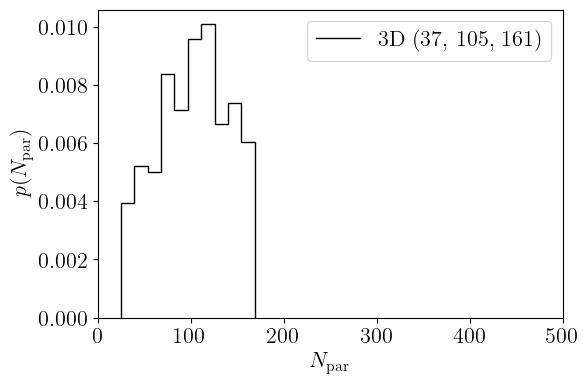

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{par}}$",
    ylabel=r"$p(N_{\mathrm{par}})$",
    xlim=(0, 500),
)

ls = ["-", "--", ":"]

ind=0
ndim=3

n_params = tri_sizes * (ndim + 1) + 2**ndim + 1

l, m, h = np.quantile(n_params, [0.05, 0.5, 0.95]).astype(int)

hist, edges = np.histogram(n_params, density=True)
ax.stairs(
    hist,
    edges, 
    color='black', 
    ls=ls[ind], 
    label=f"{ndim}D ({l}, {m}, {h})"
)

ax.legend()
plt.show()
plt.close()

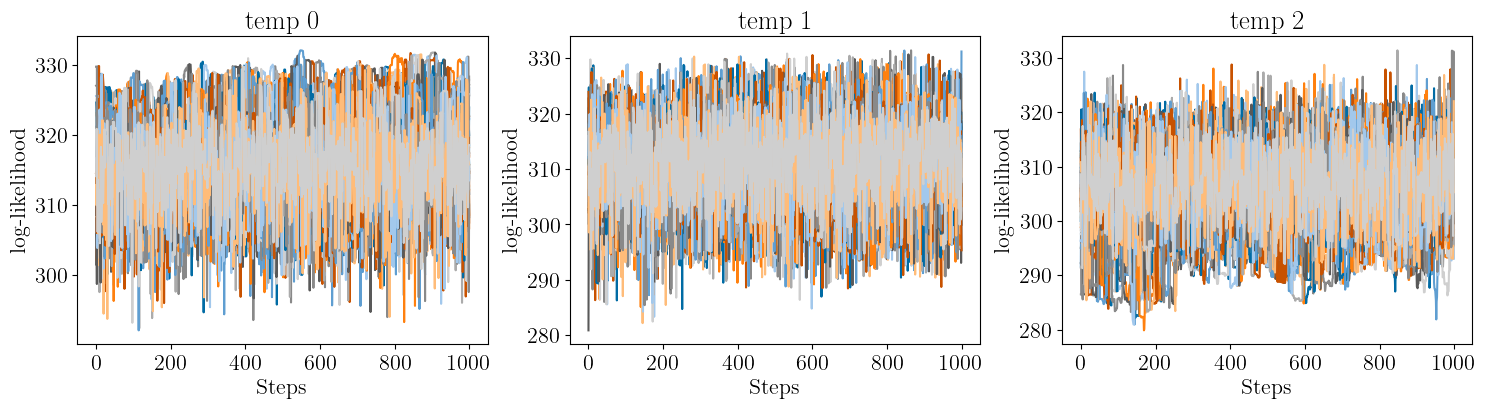

In [11]:
fig, axes = plt.subplots(1, ntemps, figsize=(18,4))
for t,w in product(range(ntemps),range(nwalkers)):
    ax = axes[t]
    ax.plot(back.get_log_like()[:, t, w])
    ax.set(title=f"temp {t}")
    ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-likelihood")
plt.show()
plt.close()

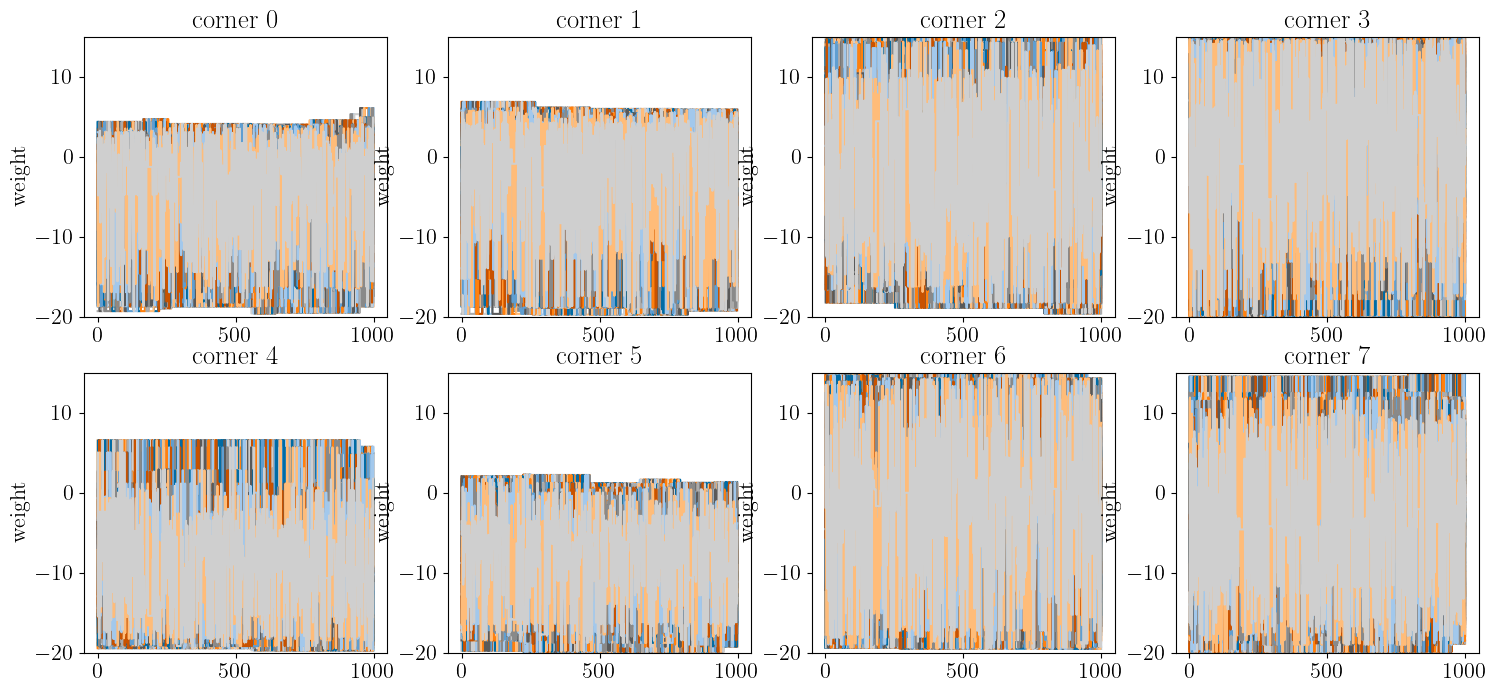

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for n in range(len(corners_3d)):
    ax = axes[n//4, n%4]
    for t,w in product(range(ntemps),range(nwalkers)):
        ax.plot(np.ravel(back.chain['corner_w'][:,t,w,0,n]))
    ax.set(title=f"corner {n}")
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"weight")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Load triangulations

In [13]:
all_triangulations = []
for t in range(ntemps):
    triangulations = [
        back.chain["tri"][step, t, walker][back.inds["tri"][step, t, walker]]
        for step, walker in product(range(nsteps), range(nwalkers))
    ]
    corner_weights = np.array(
        [
            back.chain["corner_w"][step, t, walker]
            for step, walker in product(range(nsteps), range(nwalkers))
        ]
    )
    for ind in tqdm(range(len(triangulations))):
        all_triangulations.extend([
            np.vstack([triangulations[ind], np.c_[corners_3d, corner_weights[ind].T]])                
        ])

100%|██████████████████████████████████████████████████████████████████████████████████████████| 40000/40000 [00:00<00:00, 224559.72it/s]


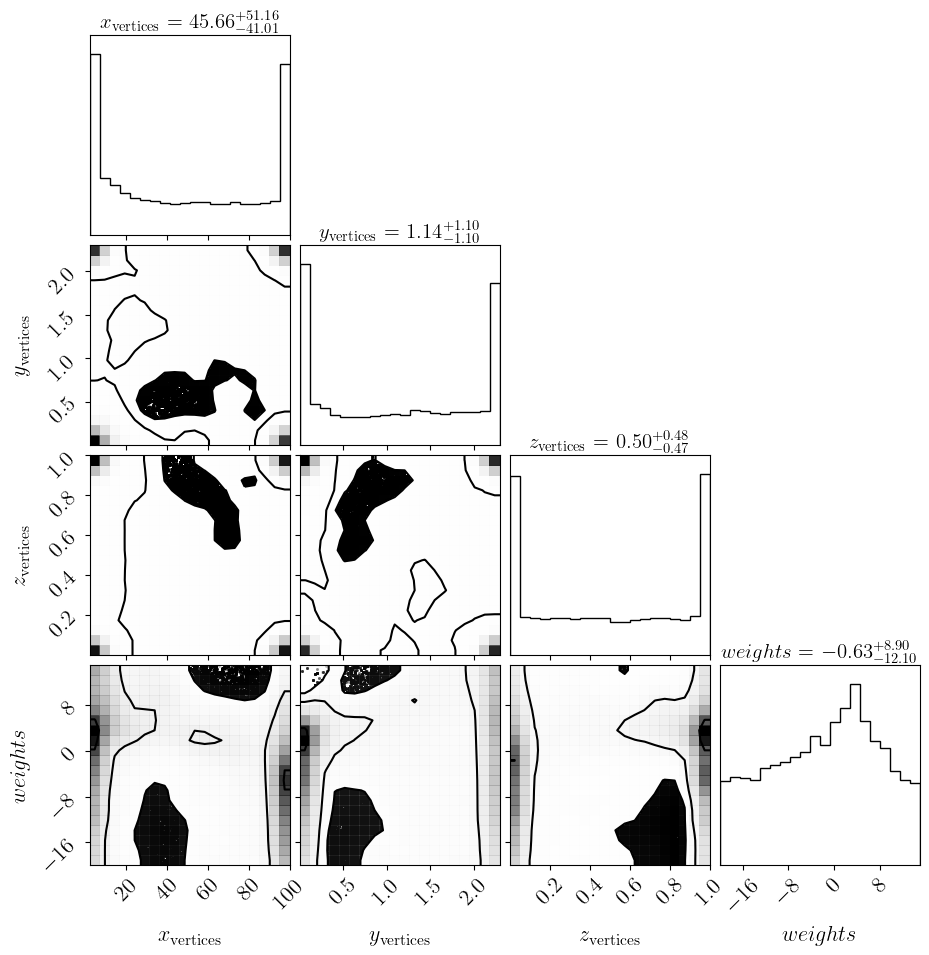

In [14]:
ws = np.hstack([tri[:, -1] for tri in all_triangulations])
vertices = np.vstack([tri[:, :-1] for tri in all_triangulations])    
corner_plot(np.c_[vertices, ws], smooth=True, levels=[0.05, 0.5, 0.95],
            labels=[r"$x_\mathrm{vertices}$", r"$y_\mathrm{vertices}$", r"$z_\mathrm{vertices}$", r"$weights$"],
            show_titles=True,
            title_kwargs={"fontsize": 15},
           )
plt.show()
plt.close()

In [15]:
## Evolution of the inferred rate at a fixed point ##
targets = np.array([[10.,0.2,0.8],[35.,0.2,0.8],[35.,1.0,0.8],[35.,0.2,0.5]])
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate_at_target = np.zeros((num_triangulations,4))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_at_target[ind] = this_delo.interpolate(targets)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1459.43it/s]


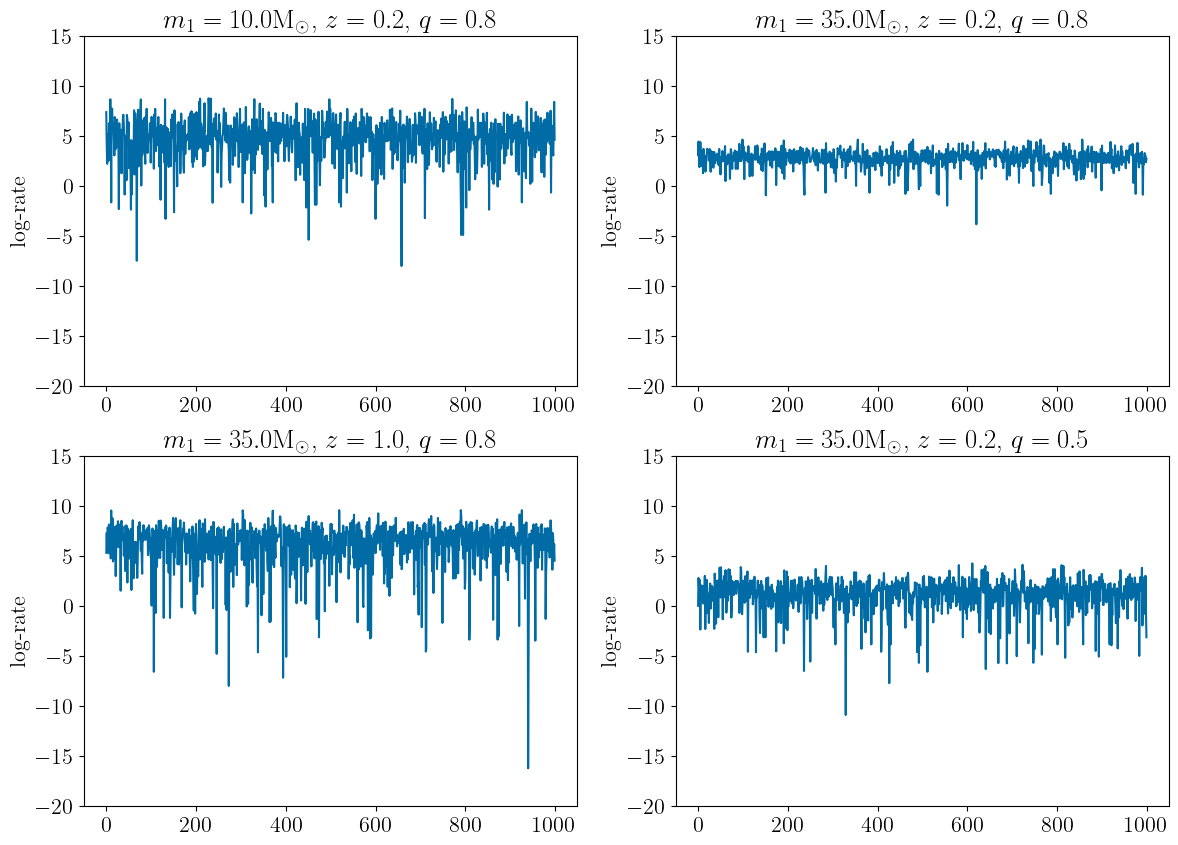

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for n in range(len(targets)):
    ax = axes[n//2, n%2]
    ax.plot(log_rate_at_target[:,n])
    ax.set(title=r"$m_1=%.1f\mathrm{M}_\odot$, $z=%.1f$, $q=%.1f$" 
           %(targets[n][0],targets[n][1],targets[n][2]))
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-rate")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Compute rate over grids

In [17]:
Tobs = 66997600.0 /(24 * 3600 * 365.25) # in years

In [18]:
m1_grid = np.linspace(m1_min, m1_max, 49)
z_grid = np.linspace(0.1, z_max, 50)
q_grid = np.linspace(q_min, q_max, 51)

X, Y, Z = np.meshgrid(m1_grid, z_grid, q_grid)
grid = np.c_[X.ravel(), Y.ravel(), Z.ravel()]

dm1 = m1_grid[1] - m1_grid[0]
dz = z_grid[1] - z_grid[0]
dq = q_grid[1] - q_grid[0]

to_comoving_volume = (1 + z_grid) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value
    )

In [19]:
# selected_tris = range(0, len(all_triangulations), 40)
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate = np.zeros((num_triangulations, grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)
    
square_rate = log_rate.reshape(num_triangulations, z_grid.shape[0], m1_grid.shape[0], q_grid.shape[0])

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:24<00:00, 41.10it/s]


In [20]:
median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

### Injections

In [21]:
injections_file = np.load("./selection_function_elements.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

## Prior

In [22]:
nsamples_prior = 1_000
log_rate_prior = np.zeros((nsamples_prior, grid.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+8,4))
    tri_i[:8,:-1] = corners_3d
    tri_i[8:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[8:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[8:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,3] = np.random.uniform(w_min, w_max, nleaves_i+8)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior[i] = this_delo.interpolate(grid)

square_rate_prior = log_rate_prior.reshape(nsamples_prior, z_grid.shape[0], m1_grid.shape[0], q_grid.shape[0])

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:33<00:00, 29.44it/s]


In [23]:
Nevents_prior = np.sum(np.exp(square_rate_prior) *to_comoving_volume[None,:,None,None], axis=(1,2,3)) *dm1 *dz *dq
median_prior = np.quantile(Nevents_prior, 0.5)
low_prior = np.quantile(Nevents_prior, 0.05)
high_prior = np.quantile(Nevents_prior, 0.95)

# Marginals

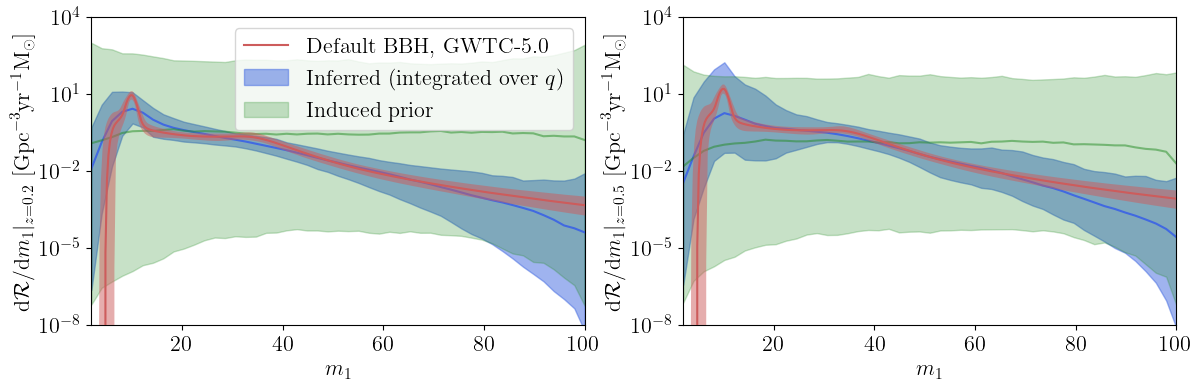

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

z_values_toplot = [0.2,1.0]
ymins = [1e-8, 1e-8]
ymaxs = [1e4, 1e4]

for n,zeval in enumerate([0.2,0.5]):
    ax = axes[n]
    redshift_factor_strong_bbh_o4b = (1 + zeval)**(strong_bbh_O4b.get_hyperparameter_samples(hyperparameters=['lamb']))
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    ax.plot(strong_bbh_O4b_m1_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.5, axis=0),
            color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
    ax.fill_between(strong_bbh_O4b_m1_grid,
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.05, axis=0),
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.95, axis=0),
            color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
    
    dRdm1_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1 = np.quantile(dRdm1_zeval, 0.05, axis=0)
    median_dRdm1 = np.quantile(dRdm1_zeval, 0.5, axis=0)
    high_dRdm1 = np.quantile(dRdm1_zeval, 0.95, axis=0)
    
    ax.plot(m1_grid, median_dRdm1, color="royalblue")
    ax.fill_between(m1_grid, low_dRdm1, high_dRdm1,
                    color="royalblue", alpha=0.5,
                    label=r'Inferred (integrated over $q$)',
                    )

    dRdm1_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.05, axis=0)
    median_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.5, axis=0)
    high_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.95, axis=0)
    ax.plot(m1_grid, median_dRdm1_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(m1_grid, low_dRdm1_prior, high_dRdm1_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$m_1$')
    ax.set_xlim(xmin=m1_grid.min(), xmax=m1_grid.max())
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}\mathrm{M}_\odot]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

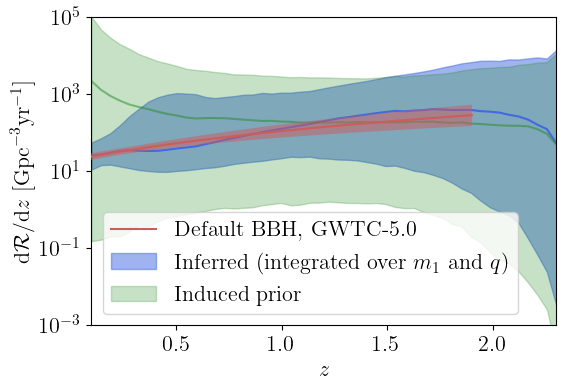

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.plot(strong_bbh_O4b_z_grid, np.quantile(strong_bbh_O4b_Rz, 0.5, axis=0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
ax.fill_between(strong_bbh_O4b_z_grid,
        np.quantile(strong_bbh_O4b_Rz, 0.05, axis=0),
        np.quantile(strong_bbh_O4b_Rz, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)

dRdz = np.sum(np.exp(square_rate) 
              *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_dRdz = np.quantile(dRdz, 0.05, axis=0)
median_dRdz = np.quantile(dRdz, 0.5, axis=0)
high_dRdz = np.quantile(dRdz, 0.95, axis=0)

ax.plot(z_grid, median_dRdz, color="royalblue")
ax.fill_between(z_grid, low_dRdz, high_dRdz,
                color="royalblue", alpha=0.5,
                label=r'Inferred (integrated over $m_1$ and $q$)',
                )

dRdz_prior = np.sum(np.exp(square_rate_prior) 
                    *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_dRdz_prior = np.quantile(dRdz_prior, 0.05, axis=0)
median_dRdz_prior = np.quantile(dRdz_prior, 0.5, axis=0)
high_dRdz_prior = np.quantile(dRdz_prior, 0.95, axis=0)
ax.plot(z_grid, median_dRdz_prior, color="forestgreen", alpha=0.5)
ax.fill_between(z_grid, low_dRdz_prior, high_dRdz_prior,
                color="forestgreen", alpha=0.25,
                label='Induced prior',
                )


ax.set_xlabel(r'$z$')
ax.set_xlim(xmin=z_grid.min(), xmax=z_grid.max())
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}z\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.legend(loc='best')
#ax.set_box_aspect(1)
ax.set_ylim(ymin=1e-3, ymax=1e5)

plt.show()
plt.close()

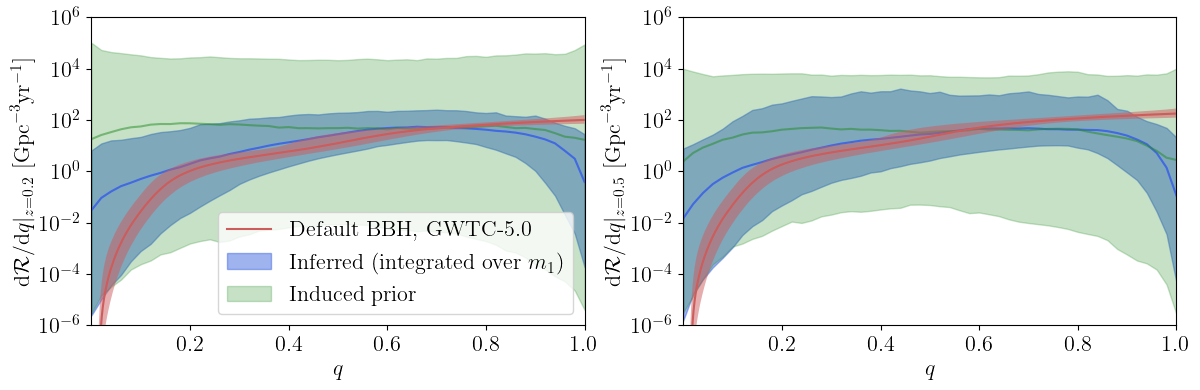

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

z_values_toplot = [0.2,1.0]
ymins = [1e-6, 1e-6]
ymaxs = [1e6, 1e6]

for n,zeval in enumerate([0.2,0.5]):
    ax = axes[n]
    redshift_factor_strong_bbh_o4b = (1 + zeval)**(strong_bbh_O4b.get_hyperparameter_samples(hyperparameters=['lamb']))
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    ax.plot(strong_bbh_O4b_q_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.5, axis=0),
            color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
    ax.fill_between(strong_bbh_O4b_q_grid,
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.05, axis=0),
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.95, axis=0),
            color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
    
    dRdq_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) 
                        *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq = np.quantile(dRdq_zeval, 0.05, axis=0)
    median_dRdq = np.quantile(dRdq_zeval, 0.5, axis=0)
    high_dRdq = np.quantile(dRdq_zeval, 0.95, axis=0)
    
    ax.plot(q_grid, median_dRdq, color="royalblue")
    ax.fill_between(q_grid, low_dRdq, high_dRdq,
                    color="royalblue", alpha=0.5,
                    label=r'Inferred (integrated over $m_1$)',
                    )
    
    dRdq_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.05, axis=0)
    median_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.5, axis=0)
    high_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.95, axis=0)
    ax.plot(q_grid, median_dRdq_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(q_grid, low_dRdq_prior, high_dRdq_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$q$')
    ax.set_xlim(xmin=q_grid.min(), xmax=q_grid.max())
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

# 95% - 5% CI 

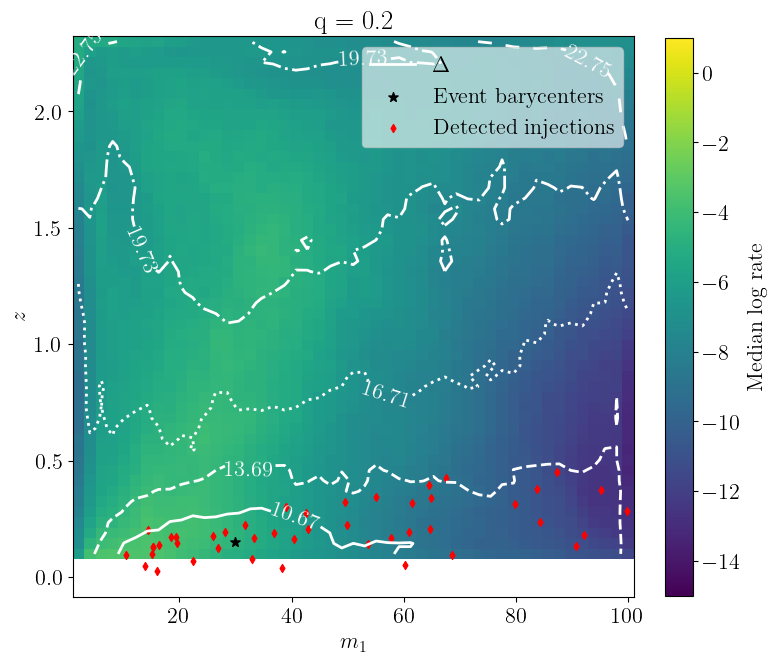

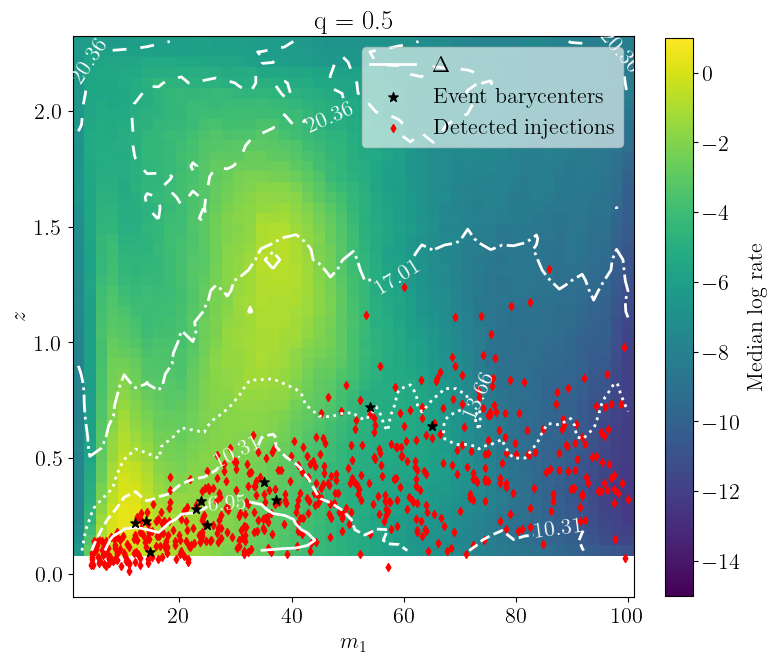

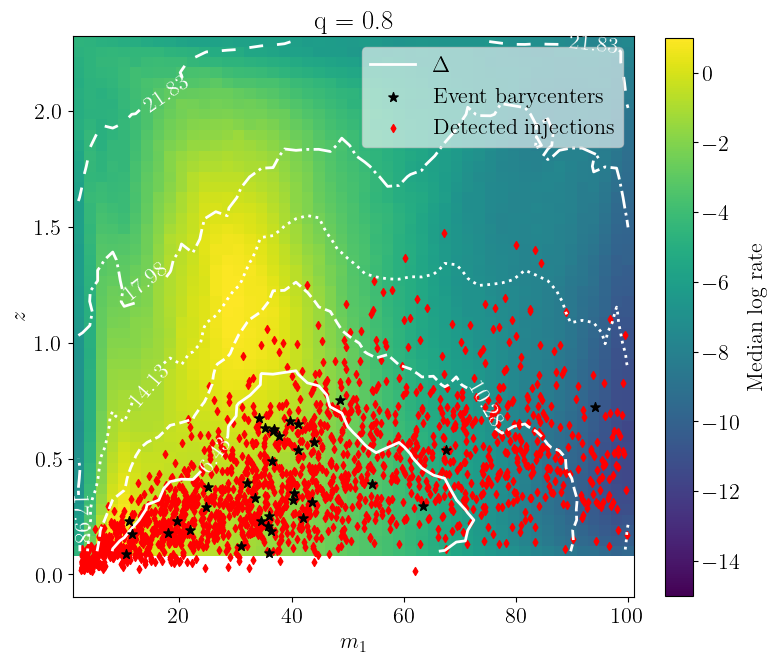

In [27]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")
    norm = mpl.colors.Normalize(vmin=-15, vmax=1)

    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                     norm=norm,
                     )
    
    # Calculate the difference
    diff = high[:, :, qeval_ind] - low[:, :, qeval_ind]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

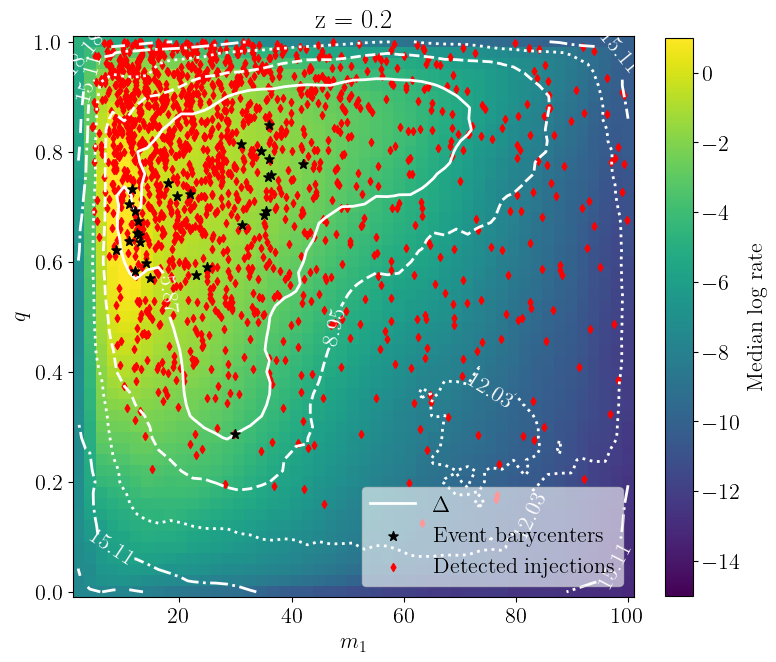

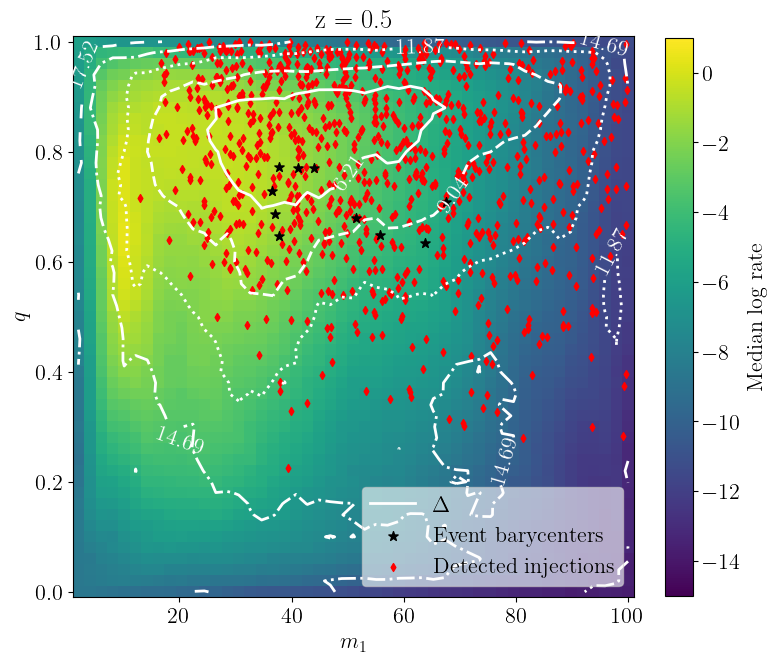

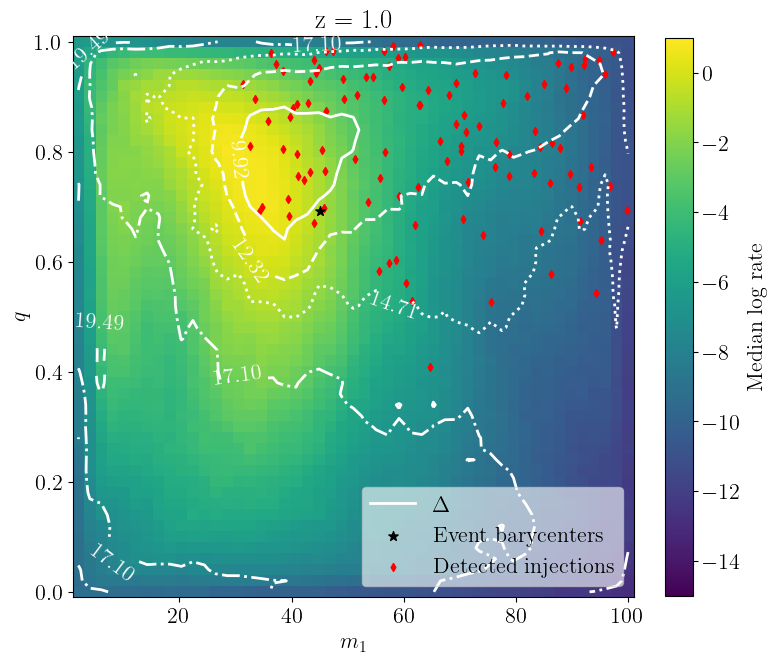

In [28]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


for zeval in [0.2, 0.5, 1.0]:
    zeval_ind = np.argmin(np.abs(z_grid-zeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"z = {z_grid[zeval_ind]:.1f}")   
    norm = mpl.colors.Normalize(vmin=-15, vmax=1)
    
    c = ax.pcolormesh(m1_grid, q_grid, median[zeval_ind, :, :].T +np.log(to_comoving_volume[zeval_ind]),
                  norm=norm,
                 )

    
    # Calculate the difference
    diff = high[zeval_ind, :, :] - low[zeval_ind, :, :]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, q_grid, diff.T, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_z = np.abs(event_barycenters[:,1]-z_grid[zeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_z,0], event_barycenters[events_at_z,2],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_z = np.abs(detected_injections[:,1]-z_grid[zeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_z,0], detected_injections[injections_at_z,2],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$q$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

# Delta

In [29]:
diff = high-low
interp_delta = RegularGridInterpolator((z_grid, m1_grid, q_grid), diff, bounds_error=False, fill_value=np.nan)

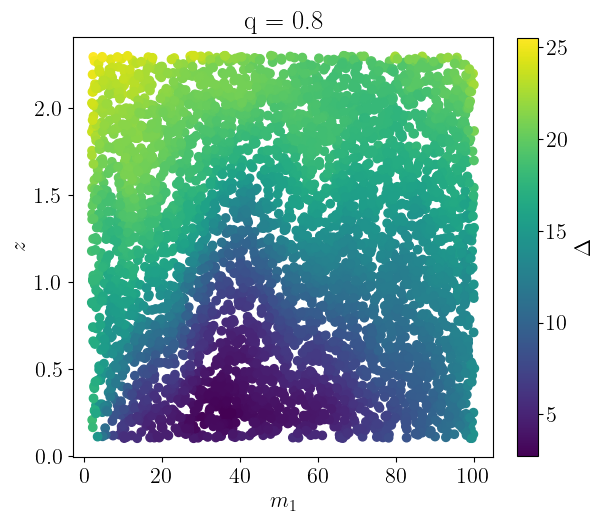

In [30]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],c=interp_delta(samples_try[:,(1,0,2)]))
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'$\Delta$')

plt.show()
plt.close()

In [31]:
delta_levels = np.linspace(np.min(diff), np.max(diff), 20)[1:-1]
print(delta_levels)

[ 4.10015892  5.61610009  7.13204126  8.64798242 10.16392359 11.67986475
 13.19580592 14.71174709 16.22768825 17.74362942 19.25957058 20.77551175
 22.29145292 23.80739408 25.32333525 26.83927641 28.35521758 29.87115875]


In [32]:
samples_per_tri = 1_000
ndraw = 10_000

ints_delta={}
ints_delta_LVK={}
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for delta in delta_levels:
    print(delta)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)

    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep       
        inds_proposal_keep=np.argwhere(interp_delta(new_points[:,(1,0,2)])<delta)[:,0]
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])
        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_delta[delta]=np.zeros(num_triangulations)
    ints_delta_LVK[delta]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)
        ints_delta[delta][ind] = mean_fx * frac_kept * volume
        
    for ind, pop_ind in enumerate(tqdm(selected_pop_LVK)):
        int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, 
                                 y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind])
        int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, 
                                y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[pop_ind])
        pdf_m1 = interp1d(x=strong_bbh_O4b_m1_grid, 
                          y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind] /int_dRdm1, 
                          fill_value="extrapolate")
        rate_z = interp1d(x=strong_bbh_O4b_z_grid, 
                          y=strong_bbh_O4b_Rz[0], 
                          fill_value="extrapolate")
        pdf_q = interp1d(x=strong_bbh_O4b_q_grid, 
                         y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[pop_ind] /int_dRdq, 
                         fill_value="extrapolate")
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_delta_LVK[delta][ind] = mean_Nx * frac_kept * volume

4.1001589232482285


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 23.59it/s]


5.616100089268044


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 23.75it/s]


7.132041255287859


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 24.78it/s]


28.355217579565274


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 23.20it/s]


29.871158745585088


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 23.23it/s]


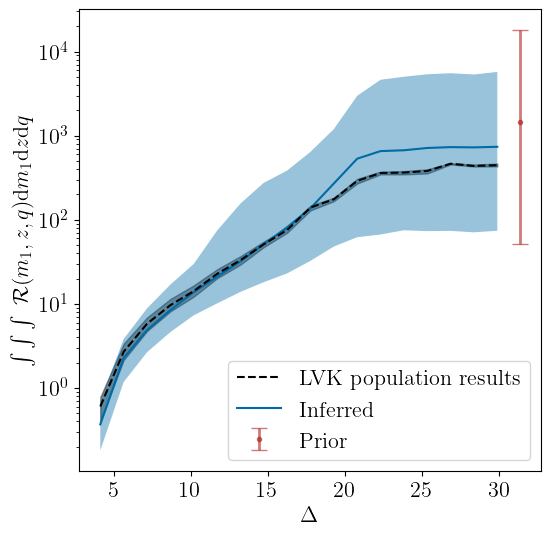

In [33]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_delta_LVK[delta]) for delta in delta_levels]
low_LVK = [ np.quantile(ints_delta_LVK[delta], 0.05) for delta in delta_levels]
high_LVK = [ np.quantile(ints_delta_LVK[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(delta_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_delta = [ np.median(ints_delta[delta]) for delta in delta_levels]
low_delta = [ np.quantile(ints_delta[delta], 0.05) for delta in delta_levels]
high_delta = [ np.quantile(ints_delta[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_delta, label='Inferred')
ax.fill_between(delta_levels, low_delta, high_delta, alpha=0.4)

ax.errorbar(delta_levels[-1]*1.05, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower right')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

# KL divergences

In [34]:
m1_grid_coarse = np.linspace(m1_min, m1_max, 19)
z_grid_coarse = np.linspace(0.1, z_max, 20)
q_grid_coarse = np.linspace(q_min, q_max, 21)

X_coarse, Y_coarse, Z_coarse = np.meshgrid(m1_grid_coarse, z_grid_coarse, q_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel(), Z_coarse.ravel()]

dm1_coarse = m1_grid_coarse[1] - m1_grid_coarse[0]
dz_coarse = z_grid_coarse[1] - z_grid_coarse[0]
dq_coarse = q_grid_coarse[1] - q_grid_coarse[0]

to_comoving_volume_coarse = (1 + z_grid_coarse) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid_coarse).to(u.Gpc**3 / u.sr).value
    )

In [35]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 342.13it/s]


In [36]:
nsamples_prior = 1_000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+8,4))
    tri_i[:8,:-1] = corners_3d
    tri_i[8:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[8:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[8:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,3] = np.random.uniform(w_min, w_max, nleaves_i+8)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)

square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 319.93it/s]


In [37]:
kl_divs=np.zeros((len(z_grid_coarse),len(m1_grid_coarse),len(q_grid_coarse)))

for i,j,k in product(range(z_grid_coarse.shape[0]),range(m1_grid_coarse.shape[0]),range(q_grid_coarse.shape[0])):
    kl_divs[i,j,k] = kl_divergence_kde(square_rate_coarse[:,i,j,k],square_rate_prior_coarse[:,i,j,k])

In [38]:
interp_kl = RegularGridInterpolator((z_grid_coarse, m1_grid_coarse, q_grid_coarse), kl_divs, bounds_error=False, fill_value=np.nan)

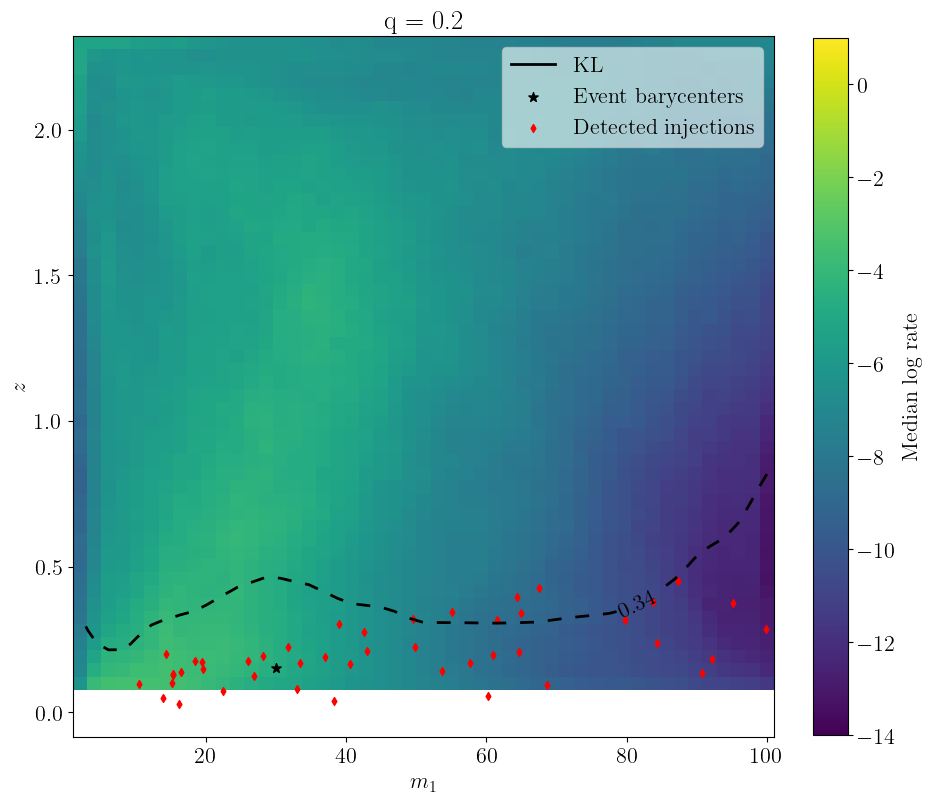

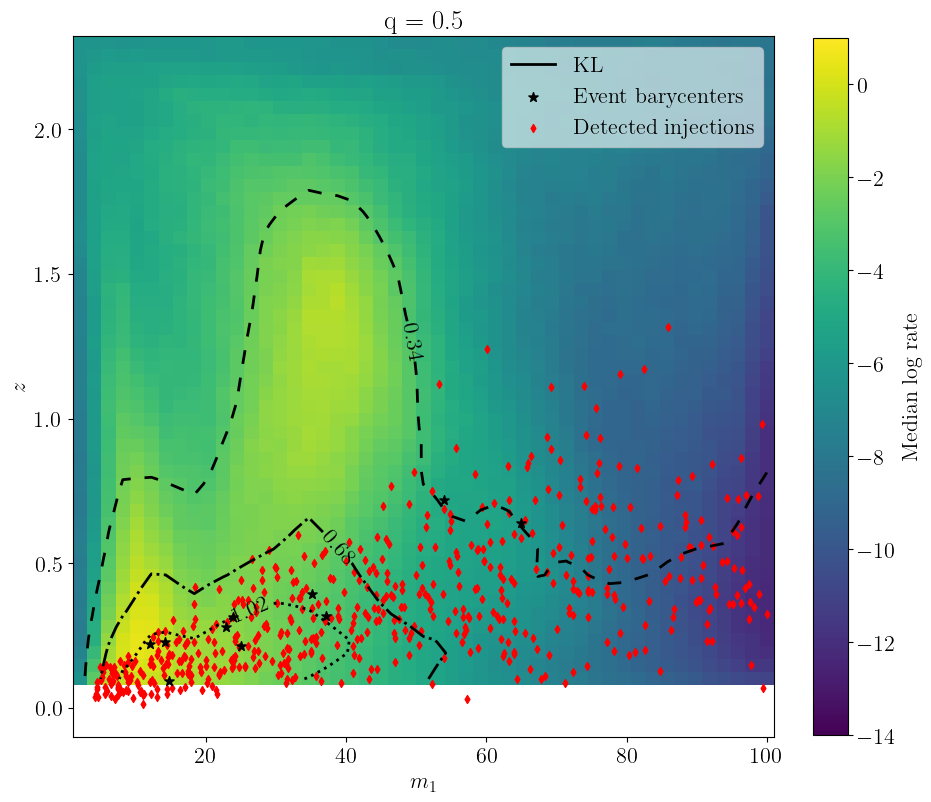

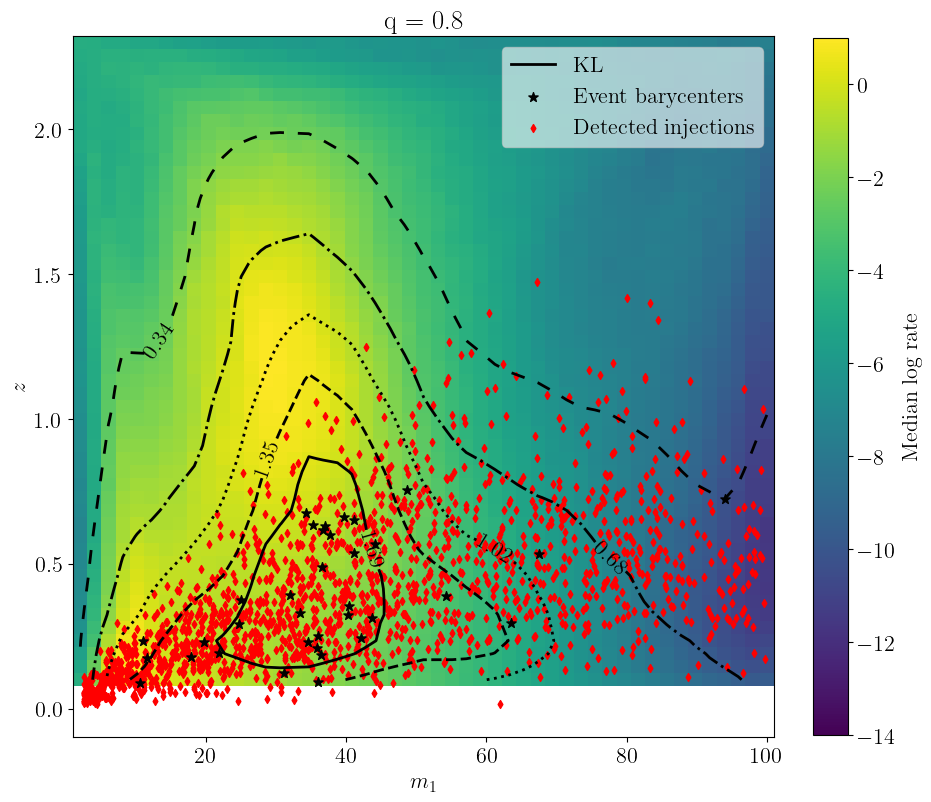

In [39]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")
    norm = mpl.colors.Normalize(vmin=-14, vmax=1)

    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                     norm=norm,
                     )

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    Xz0, Yz0, Zz0 = np.meshgrid(m1_grid, z_grid, np.array([q_grid[qeval_ind]]))
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        m1_grid, z_grid, interp_kl(grid_z0).reshape(len(z_grid),len(m1_grid)), 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

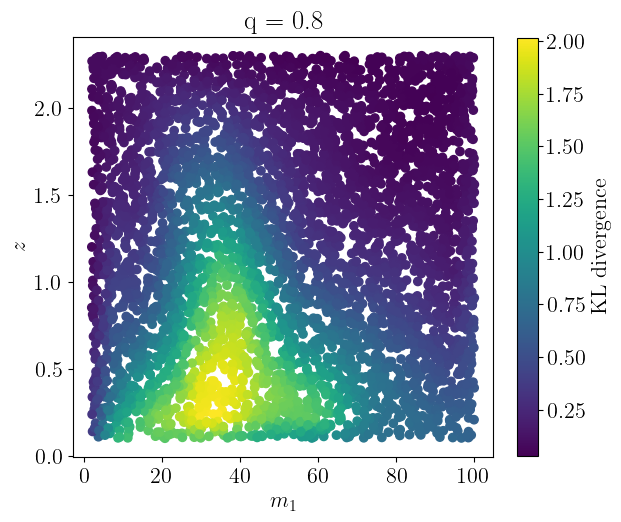

In [40]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],c=interp_kl(samples_try[:,(1,0,2)]))
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'KL divergence')

plt.show()
plt.close()

In [41]:
kl_levels = np.linspace(0, np.max(kl_divs), 20)[1:-1]
print(kl_levels)

[0.10672445 0.21344891 0.32017336 0.42689781 0.53362226 0.64034672
 0.74707117 0.85379562 0.96052008 1.06724453 1.17396898 1.28069343
 1.38741789 1.49414234 1.60086679 1.70759125 1.8143157  1.92104015]


In [42]:
samples_per_tri = 1_000
ndraw = 10_000

ints_kl={}
ints_kl_LVK={}
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for kl in np.flip(kl_levels):
    print(kl)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)
    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points[:,(1,0,2)])>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])

        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_kl[kl]=np.zeros(num_triangulations)
    ints_kl_LVK[kl]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)        
        ints_kl[kl][ind]= mean_fx * frac_kept * volume

    for ind, pop_ind in enumerate(tqdm(selected_pop_LVK)):
        int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, 
                                 y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind])
        int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, 
                                y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[pop_ind])
        pdf_m1 = interp1d(x=strong_bbh_O4b_m1_grid, 
                          y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind] /int_dRdm1, 
                          fill_value="extrapolate")
        rate_z = interp1d(x=strong_bbh_O4b_z_grid, 
                          y=strong_bbh_O4b_Rz[0], 
                          fill_value="extrapolate")
        pdf_q = interp1d(x=strong_bbh_O4b_q_grid, 
                         y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[pop_ind] /int_dRdq, 
                         fill_value="extrapolate")
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_kl_LVK[kl][ind] = mean_Nx * frac_kept * volume

1.9210401519163265


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 36.98it/s]


1.8143156990320861


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 38.34it/s]


1.7075912461478457


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 34.73it/s]


0.21344890576848072


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 34.39it/s]


0.10672445288424036


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 34.20it/s]


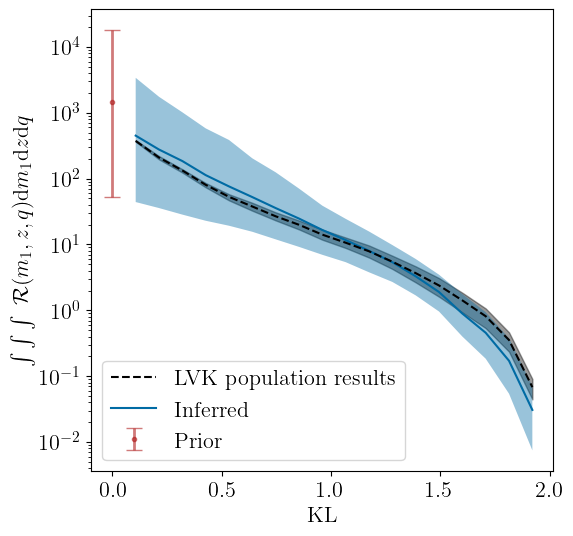

In [44]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_kl_LVK[delta]) for delta in kl_levels]
low_LVK = [ np.quantile(ints_kl_LVK[delta], 0.05) for delta in kl_levels]
high_LVK = [ np.quantile(ints_kl_LVK[delta], 0.95) for delta in kl_levels]

ax.plot(kl_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(kl_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_kl = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low_kl = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high_kl = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]

ax.plot(kl_levels, median_kl, label='Inferred')
ax.fill_between(kl_levels, low_kl, high_kl, alpha=0.4)

ax.errorbar(0, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

ax.set_xlabel(r'KL')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower left')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()